In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

conn = sqlite3.connect('../db/rentals.db')
df = pd.read_sql_query("""
    SELECT li.*, l.locality_name, l.locality_group, l.is_sparse
    FROM listings li
    JOIN localities l ON li.locality_id = l.locality_id
""", conn)

df['log_price'] = np.log(df['price'])

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['locality_group']
)

print(f"Train: {len(train_df)} rows, Test: {len(test_df)} rows")
print(train_df['locality_group'].value_counts(normalize=True).sort_index())
print(test_df['locality_group'].value_counts(normalize=True).sort_index())

Train: 13857 rows, Test: 3465 rows
locality_group
Delhi Central       0.154868
Delhi East          0.107671
Delhi North         0.009670
Delhi South         0.206755
Delhi West          0.015227
Dwarka              0.139713
North Delhi         0.071011
North West Delhi    0.000577
Other               0.147579
Rohini              0.015732
South West Delhi    0.004619
West Delhi          0.126579
Name: proportion, dtype: float64
locality_group
Delhi Central       0.154978
Delhi East          0.107648
Delhi North         0.009524
Delhi South         0.206638
Delhi West          0.015296
Dwarka              0.139683
North Delhi         0.070996
North West Delhi    0.000577
Other               0.147763
Rohini              0.015584
South West Delhi    0.004618
West Delhi          0.126696
Name: proportion, dtype: float64


In [2]:
features = ['size_sq_ft', 'bedrooms', 'closest_metro_km', 'airport_dist_km',
            'aiims_dist_km', 'ndrlw_dist_km', 'locality_group', 'property_type']
target = 'log_price'

X_train = pd.get_dummies(train_df[features], columns=['locality_group', 'property_type'], drop_first=True)
X_test = pd.get_dummies(test_df[features], columns=['locality_group', 'property_type'], drop_first=True)

# Align columns in case a category appears in one split but not the other
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df[target]
y_test = test_df[target]

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

baseline = LinearRegression()
baseline.fit(X_train, y_train)
pred_log = baseline.predict(X_test)

# Convert back to actual rupees for interpretable MAE
pred_price = np.exp(pred_log)
actual_price = np.exp(y_test)

print("Baseline Linear Regression:")
print("R² (log scale):", r2_score(y_test, pred_log))
print("MAE (₹):", mean_absolute_error(actual_price, pred_price))
print("MAE as % of median price:", mean_absolute_error(actual_price, pred_price) / actual_price.median() * 100)

Baseline Linear Regression:
R² (log scale): 0.7276817056891891
MAE (₹): 7511.96555490199
MAE as % of median price: 35.771264547152356


In [3]:
results = pd.DataFrame({
    'actual': actual_price,
    'predicted': pred_price,
    'abs_error': np.abs(actual_price - pred_price)
})
results['pct_error'] = results['abs_error'] / results['actual'] * 100

print(results['abs_error'].describe())
print()
print(results.sort_values('abs_error', ascending=False).head(10))
print()
print("Median % error (more robust than mean):", results['pct_error'].median())

count      3465.000000
mean       7511.965555
std       12376.867578
min           1.251840
25%        1821.763734
50%        4060.590583
75%        8061.808317
max      160591.584735
Name: abs_error, dtype: float64

         actual      predicted      abs_error   pct_error
4572    70000.0  230591.584735  160591.584735  229.416550
7453   180000.0   23419.586478  156580.413522   86.989119
7456   150000.0   16301.013677  133698.986323   89.132658
8891   140000.0   15621.549730  124378.450270   88.841750
14006   20000.0  141021.382168  121021.382168  605.106911
16121  150000.0   31065.758502  118934.241498   79.289494
16530   75000.0  193417.685043  118417.685043  157.890247
3082   200000.0   86489.000777  113510.999223   56.755500
15950  140000.0   27635.004200  112364.995800   80.260711
13992  170000.0   59105.898909  110894.101091   65.231824

Median % error (more robust than mean): 19.90914558299425


In [4]:
print("MAE (log scale):", mean_absolute_error(y_test, pred_log))

MAE (log scale): 0.2557515163478863


In [5]:
worst = results.sort_values('abs_error', ascending=False).head(20).index
print(train_df.loc[train_df.index.isin(worst)] if False else test_df.loc[worst][['size_sq_ft','bedrooms','property_type','locality_group','price']])

       size_sq_ft  bedrooms      property_type locality_group   price
4572         4000         4  Independent Floor    Delhi South   70000
7453         1345         2          Apartment     West Delhi  180000
7456         1125         1          Apartment     West Delhi  150000
8891          720         1          Apartment    North Delhi  140000
14006        3200         5  Independent Floor  Delhi Central   20000
16121        1000         4  Independent Floor          Other  150000
16530        3800         4              Villa          Other   75000
3082         2750         3  Independent Floor    Delhi South  200000
15950        1300         2          Apartment          Other  140000
13992        2000         3          Apartment  Delhi Central  170000
3223         2300         4  Independent Floor    Delhi South  180000
5362         3000         3  Independent Floor    Delhi South  215000
6586         1000         3  Independent Floor     West Delhi  125000
3393         3600   

In [6]:
print((df['size_sq_ft'] == 4500).sum(), "rows with size exactly 4500")
print(df[df['size_sq_ft']==4500]['price'].describe())

# check for other suspicious "round number cliff" values
print(df['size_sq_ft'].value_counts().head(10))

0 rows with size exactly 4500
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: price, dtype: float64
size_sq_ft
900     1546
1800    1059
1000     836
500      722
450      681
600      557
1200     463
800      454
750      411
1500     403
Name: count, dtype: int64


In [7]:
results = pd.DataFrame({
    'actual': actual_price,
    'predicted': pred_price,
    'abs_error': np.abs(actual_price - pred_price)
})
results['pct_error'] = results['abs_error'] / results['actual'] * 100

print(results['abs_error'].describe())
print()
print(results.sort_values('abs_error', ascending=False).head(10))
print()
print("Median % error:", results['pct_error'].median())
print("MAE (log scale):", mean_absolute_error(y_test, pred_log))

count      3465.000000
mean       7511.965555
std       12376.867578
min           1.251840
25%        1821.763734
50%        4060.590583
75%        8061.808317
max      160591.584735
Name: abs_error, dtype: float64

         actual      predicted      abs_error   pct_error
4572    70000.0  230591.584735  160591.584735  229.416550
7453   180000.0   23419.586478  156580.413522   86.989119
7456   150000.0   16301.013677  133698.986323   89.132658
8891   140000.0   15621.549730  124378.450270   88.841750
14006   20000.0  141021.382168  121021.382168  605.106911
16121  150000.0   31065.758502  118934.241498   79.289494
16530   75000.0  193417.685043  118417.685043  157.890247
3082   200000.0   86489.000777  113510.999223   56.755500
15950  140000.0   27635.004200  112364.995800   80.260711
13992  170000.0   59105.898909  110894.101091   65.231824

Median % error: 19.90914558299425
MAE (log scale): 0.2557515163478863


In [8]:
worst2 = results.sort_values('abs_error', ascending=False).head(10).index
print(test_df.loc[worst2][['size_sq_ft','bedrooms','property_type','locality_group','price']])

       size_sq_ft  bedrooms      property_type locality_group   price
4572         4000         4  Independent Floor    Delhi South   70000
7453         1345         2          Apartment     West Delhi  180000
7456         1125         1          Apartment     West Delhi  150000
8891          720         1          Apartment    North Delhi  140000
14006        3200         5  Independent Floor  Delhi Central   20000
16121        1000         4  Independent Floor          Other  150000
16530        3800         4              Villa          Other   75000
3082         2750         3  Independent Floor    Delhi South  200000
15950        1300         2          Apartment          Other  140000
13992        2000         3          Apartment  Delhi Central  170000


In [9]:
import lightgbm as lgb

# LightGBM handles categoricals natively - no need for one-hot/get_dummies
lgb_features = ['size_sq_ft', 'bedrooms', 'closest_metro_km', 'airport_dist_km',
                'aiims_dist_km', 'ndrlw_dist_km', 'locality_group', 'property_type']

X_train_lgb = train_df[lgb_features].copy()
X_test_lgb = test_df[lgb_features].copy()

for col in ['locality_group', 'property_type']:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)
lgb_model.fit(
    X_train_lgb, y_train,
    categorical_feature=['locality_group', 'property_type']
)

lgb_pred_log = lgb_model.predict(X_test_lgb)
lgb_pred_price = np.exp(lgb_pred_log)

print("LightGBM:")
print("R² (log scale):", r2_score(y_test, lgb_pred_log))
print("MAE (₹):", mean_absolute_error(actual_price, lgb_pred_price))
print("MAE as % of median price:", mean_absolute_error(actual_price, lgb_pred_price) / actual_price.median() * 100)

lgb_results = pd.DataFrame({'actual': actual_price, 'predicted': lgb_pred_price})
lgb_results['pct_error'] = np.abs(lgb_results['actual']-lgb_results['predicted'])/lgb_results['actual']*100
print("Median % error:", lgb_results['pct_error'].median())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1264
[LightGBM] [Info] Number of data points in the train set: 13857, number of used features: 8
[LightGBM] [Info] Start training from score 10.007300
LightGBM:
R² (log scale): 0.8609697912681746
MAE (₹): 4988.961066403764
MAE as % of median price: 23.756957459065557
Median % error: 12.739363412247986


In [10]:
train_pred_log = lgb_model.predict(X_train_lgb)
print("Train R² (log scale):", r2_score(y_train, train_pred_log))
print("Test R² (log scale):", r2_score(y_test, lgb_pred_log))

Train R² (log scale): 0.9134933242210855
Test R² (log scale): 0.8609697912681746


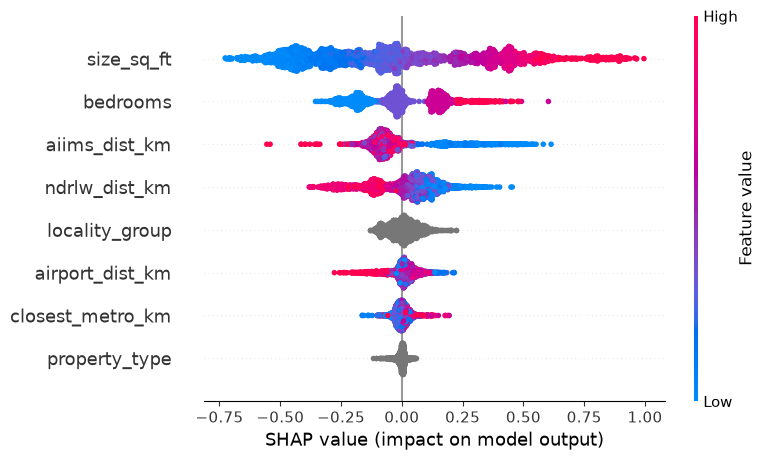

In [11]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_lgb)

# Global feature importance - which features matter most overall
shap.summary_plot(shap_values, X_test_lgb, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig('../docs/shap_summary.png')
plt.show()

In [12]:
# Pick one specific test listing to explain individually
idx = 0  # try a few different indices
listing_shap = shap_values[idx]

explanation = pd.DataFrame({
    'feature': X_test_lgb.columns,
    'value': X_test_lgb.iloc[idx].values,
    'shap_impact': listing_shap
}).sort_values('shap_impact', key=abs, ascending=False)

print(f"Actual price: ₹{actual_price.iloc[idx]:,.0f}")
print(f"Predicted price: ₹{lgb_pred_price[idx]:,.0f}")
print(explanation)

Actual price: ₹10,500
Predicted price: ₹11,794
            feature       value  shap_impact
0        size_sq_ft         500    -0.453796
4     aiims_dist_km   15.514042    -0.082024
6    locality_group  West Delhi    -0.052725
2  closest_metro_km    0.678442    -0.034326
1          bedrooms           2    -0.032436
5     ndrlw_dist_km   11.916831     0.030092
7     property_type   Apartment    -0.012637
3   airport_dist_km   13.190977     0.005892


In [13]:
# find a badly-mispredicted listing's positional index
worst_positional_idx = np.argmax(np.abs(lgb_pred_price - actual_price.values))
print(f"Actual: ₹{actual_price.iloc[worst_positional_idx]:,.0f}, Predicted: ₹{lgb_pred_price[worst_positional_idx]:,.0f}")

listing_shap = shap_values[worst_positional_idx]
explanation = pd.DataFrame({
    'feature': X_test_lgb.columns,
    'value': X_test_lgb.iloc[worst_positional_idx].values,
    'shap_impact': listing_shap
}).sort_values('shap_impact', key=abs, ascending=False)
print(explanation)

Actual: ₹180,000, Predicted: ₹23,331
            feature       value  shap_impact
0        size_sq_ft        1345     0.246090
4     aiims_dist_km   15.514042    -0.076782
1          bedrooms           2    -0.049655
6    locality_group  West Delhi    -0.033488
2  closest_metro_km    0.678442    -0.029329
7     property_type   Apartment    -0.020008
5     ndrlw_dist_km   11.916831     0.017083
3   airport_dist_km   13.190977    -0.003660


In [14]:
# Check other listings with same size/bedroom/locality profile for comparison
similar = df[(df['locality_group']=='West Delhi') & (df['bedrooms']==2) &
             (df['size_sq_ft'].between(1000,1600))]
print(similar[['size_sq_ft','price']].describe())

        size_sq_ft          price
count   260.000000     260.000000
mean   1155.303846   23416.923077
std     160.381507   11376.417649
min    1000.000000    6000.000000
25%    1000.000000   19000.000000
50%    1100.000000   22000.000000
75%    1250.000000   25000.000000
max    1600.000000  180000.000000


In [15]:
fairness_df = test_df.copy()
fairness_df['predicted_price'] = lgb_pred_price
fairness_df['actual_price'] = actual_price.values

# % deviation of actual from predicted (positive = overpriced, negative = underpriced)
fairness_df['pct_deviation'] = (fairness_df['actual_price'] - fairness_df['predicted_price']) / fairness_df['predicted_price'] * 100

# Confidence band based on the model's typical error (median % error ~12.7%)
# Anything within +/- 1 typical error band = "fair", beyond 2x = "significantly" over/under
median_err_pct = 12.74  # from earlier

def classify(pct_dev):
    if pct_dev > 2 * median_err_pct:
        return 'Significantly overpriced'
    elif pct_dev > median_err_pct:
        return 'Somewhat overpriced'
    elif pct_dev < -2 * median_err_pct:
        return 'Significantly underpriced'
    elif pct_dev < -median_err_pct:
        return 'Somewhat underpriced'
    else:
        return 'Fair'

fairness_df['fairness_label'] = fairness_df['pct_deviation'].apply(classify)
print(fairness_df['fairness_label'].value_counts())

fairness_label
Fair                         1735
Somewhat underpriced          581
Somewhat overpriced           459
Significantly overpriced      442
Significantly underpriced     248
Name: count, dtype: int64


In [16]:
print(fairness_df[fairness_df['fairness_label']=='Significantly overpriced'][['actual_price','predicted_price','pct_deviation']].sort_values('pct_deviation', ascending=False).head(10))

       actual_price  predicted_price  pct_deviation
16191       95000.0     10912.240267     770.582004
7453       180000.0     23331.254960     671.497291
7456       150000.0     24683.920843     507.683038
6586       125000.0     25367.273116     392.760887
8891       140000.0     32272.080624     333.811509
6960        75000.0     18009.413130     316.448884
13992      170000.0     43545.618928     290.395186
15950      140000.0     36271.639002     285.976493
8892       110000.0     30845.515364     256.615860
16424       63000.0     19949.743873     215.793528


In [17]:
print(fairness_df[fairness_df['fairness_label']=='Significantly overpriced'][
    ['actual_price','predicted_price','pct_deviation','size_sq_ft','bedrooms','property_type','locality_group']
].sort_values('pct_deviation', ascending=False).head(15))

print()
print(fairness_df[fairness_df['fairness_label']=='Significantly overpriced']['pct_deviation'].describe())

       actual_price  predicted_price  pct_deviation  size_sq_ft  bedrooms  \
16191       95000.0     10912.240267     770.582004         600         1   
7453       180000.0     23331.254960     671.497291        1345         2   
7456       150000.0     24683.920843     507.683038        1125         1   
6586       125000.0     25367.273116     392.760887        1000         3   
8891       140000.0     32272.080624     333.811509         720         1   
6960        75000.0     18009.413130     316.448884        1500         1   
13992      170000.0     43545.618928     290.395186        2000         3   
15950      140000.0     36271.639002     285.976493        1300         2   
8892       110000.0     30845.515364     256.615860         585         1   
16424       63000.0     19949.743873     215.793528        1150         2   
10468       80000.0     28936.451841     176.467897        1650         3   
1336        85000.0     31326.631401     171.334632        1000         4   

In [18]:
print(fairness_df[fairness_df['fairness_label']=='Significantly overpriced']['pct_deviation'].describe())

count    442.000000
mean      55.163123
std       64.425112
min       25.552960
25%       30.892919
50%       40.131687
75%       52.762794
max      770.582004
Name: pct_deviation, dtype: float64


In [19]:
sig = fairness_df[fairness_df['fairness_label']=='Significantly overpriced']['pct_deviation']
print("min:", sig.min())
print("25%:", sig.quantile(0.25))
print("50%:", sig.median())
print("75%:", sig.quantile(0.75))
print("max:", sig.max())

min: 25.552959842997257
25%: 30.892919030841117
50%: 40.13168715959299
75%: 52.76279448731801
max: 770.5820040590321


In [20]:
# Score the FULL dataset (train + test) using the already-trained model.
# This is not leakage - we're not retraining, just applying a frozen model
# to generate fairness scores for browsing. Evaluation metrics (R², MAE)
# reported earlier remain test-set-only and should stay that way in the README.

full_df = df.copy()  # the original full cleaned dataframe from the top of this notebook

X_full_lgb = full_df[lgb_features].copy()
for col in ['locality_group', 'property_type']:
    X_full_lgb[col] = X_full_lgb[col].astype('category')

full_pred_log = lgb_model.predict(X_full_lgb)
full_pred_price = np.exp(full_pred_log)

full_df['predicted_price'] = full_pred_price
full_df['actual_price'] = full_df['price']
full_df['pct_deviation'] = (full_df['actual_price'] - full_df['predicted_price']) / full_df['predicted_price'] * 100

# mark which rows were actually held out during evaluation, for transparency
full_df['was_test_set'] = full_df.index.isin(test_df.index)

full_df['fairness_label'] = full_df['pct_deviation'].apply(classify)

print(full_df['fairness_label'].value_counts())
print(f"\nTotal listings scored: {len(full_df)}")

fairness_label
Fair                         9656
Somewhat underpriced         2683
Somewhat overpriced          2274
Significantly overpriced     1764
Significantly underpriced     945
Name: count, dtype: int64

Total listings scored: 17322


In [21]:
import joblib
from pathlib import Path

MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

# Save the trained model
joblib.dump(lgb_model, MODEL_DIR / 'lgb_rent_model.pkl')

# Save the exact feature list and column order the model expects —
# critical so the dashboard builds input rows in the right shape later
joblib.dump(lgb_features, MODEL_DIR / 'feature_list.pkl')

# Save the median error used for fairness bands, so the dashboard
# uses the same threshold logic rather than a hardcoded duplicate
joblib.dump(median_err_pct, MODEL_DIR / 'median_error_pct.pkl')

print("Model artifacts saved to /models")

Model artifacts saved to /models


In [22]:
DATA_DIR = Path('../data/processed')
DATA_DIR.mkdir(exist_ok=True)

fairness_df.to_csv(DATA_DIR / 'fairness_scored_listings.csv', index=False)
print(f"Saved {len(fairness_df)} scored listings to data/processed/")

Saved 3465 scored listings to data/processed/


In [23]:
full_df.to_csv(DATA_DIR / 'fairness_scored_listings.csv', index=False)
print(f"Saved {len(full_df)} scored listings to data/processed/")

Saved 17322 scored listings to data/processed/


In [24]:
import pandas as pd
check = pd.read_csv('../data/processed/fairness_scored_listings.csv')
print(len(check))


17322
